# 02b · What the bottlenecks do to the fit

*Companion to task 02. No new fits — every panel reads the 175 grid runs and the ten dense
fits from task 01. Regions are pooled wherever they make no difference, and every plot shows
the individual seeds.*

**Two claims:**

1. **The cross-region bottleneck costs fit; the within-region bottleneck barely does.** Rank 1
   on every cross block costs 0.014–0.019 of ceiling-relative $R^2$; rank 1 on every self block
   costs at most 0.003. This holds for every fixation type and every region. (§2)
2. **Interactive face is the worst-fitted fixation type in every network, dense or
   constrained.** The bottlenecks do not change which type is hardest. (§3)

**And what the constrained network does:** it reroutes a region's drive to whichever route is
left open — through the network when self blocks are squeezed, through self-recurrence when
cross blocks are. Only the first substitution keeps the fit. (§5)

| Section | |
|---|---|
| 1 | Definitions, and what the two constraints act on |
| 2 | The main result: cost of each bottleneck, per fixation type |
| 3 | Interactive face is worst throughout |
| 4 | Regions, for completeness |
| 5 | Where a region's drive comes from |
| 6 | Other network properties (supplementary) |
| 7 | Summary |

## 1. Definitions

Region $r$ has a hidden state $h_r(t)\in\mathbb{R}^{40}$, the activity of its 40 units after the
nonlinearity. The recurrent matrix is sixteen $40\times40$ blocks, $W_{rs}$ mapping region $s$'s
state into region $r$.

| quantity | definition | what it is |
|---|---|---|
| **drive** from $s$ into $r$ | $c_{s\to r}(t) = W_{rs}\,h_s(t)$ | the 40-vector of input region $r$ receives from region $s$ at time $t$. $s=r$ is the region's **self-drive** (its own recurrence). |
| the update | $h_r(t{+}1)=\tanh\!\big(\sum_s c_{s\to r}(t)+b_r\big)$ | the state is the tanh of the total drive plus a bias |
| **drive energy** of a pathway | $\lVert c_{s\to r}(t)\rVert^2$ | squared length of that 40-vector |
| **cross share** | $\dfrac{\sum_{s\neq r}\lVert c_{s\to r}(t)\rVert^2}{\sum_{s}\lVert c_{s\to r}(t)\rVert^2}$ | the fraction of what region $r$ receives that comes from the other three regions rather than from itself. Scale-free, so comparable across cells and fixation types. |
| **state speed** | $\overline{\lVert h_r(t{+}1)-h_r(t)\rVert}$ | how far the state moves per 10 ms bin |
| **state extent** | $\overline{\lVert h_r(t)-\bar h_r\rVert}$ | how far the state sits from its mean |
| **participation ratio** of a trajectory | $(\sum_i\lambda_i)^2/\sum_i\lambda_i^2$ over covariance eigenvalues | the effective number of dimensions it occupies |
| **alignment** | $\cos\big(c_{s\to r}(t),\,c_{r\to r}(t)\big)$ | does the partner push region $r$ the way its own recurrence is already pushing it (positive) or against it (negative) |

**The two constraints.** $r_w$ = rank of each self block $W_{rr}$; $r_c$ = rank of each of the
twelve cross blocks $W_{rs}$. A region's total drive therefore has rank at most $r_w + 3r_c$
— three cross blocks feed each region — which is why the two are not compared at equal rank
but along their **marginals**: one side squeezed, the other left dense.

**What is not comparable.** Raw drive magnitudes differ across cells (a rank-constrained model
compensates with larger weights) and across fixation types (interactive face has half the
target variance). Every cross-cell and cross-condition claim below therefore uses shares,
fractions, cosines and participation ratios.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


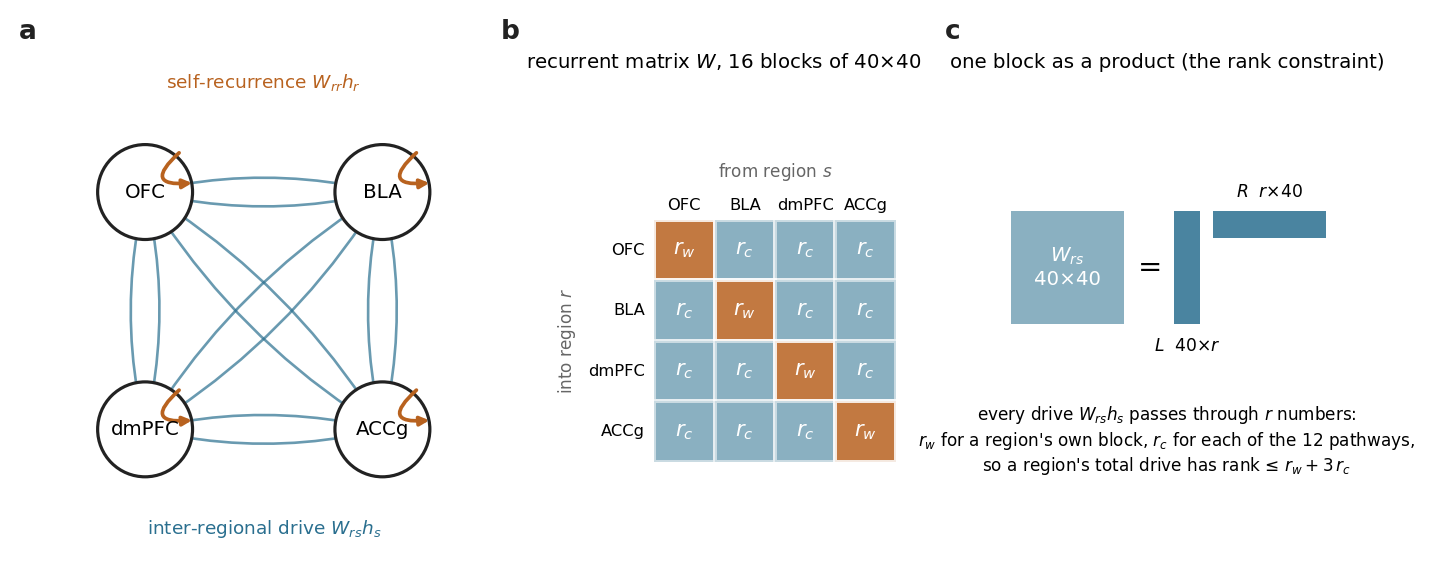

36 cells; reference cells ['full', 'w1_c10', 'w1_c1']


In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings, apply_thesis_plot_style, figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

TREE = "final"
LADDER_ROOT = sweep.resolve_task_root("01_ladder", DATASET_CFG_PATH, tree=TREE)
GRID_ROOT = sweep.resolve_task_root("02_rank_grid", DATASET_CFG_PATH, tree=TREE)
TASK_ROOT = sweep.resolve_task_root("02b_bottleneck_properties", DATASET_CFG_PATH, tree=TREE)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_02b_bottleneck_properties")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

BASE = yaml.safe_load((TASK_ROOT.parent / "base_model.yaml").read_text())
HIDDEN_UNITS = int(BASE["hidden_units"])
RANKS = (1, 2, 3, 5, 10)
ADEQUATE_BAR = 0.98
SELECTED = yaml.safe_load((GRID_ROOT / "selected_bottleneck.yaml").read_text())
REFERENCE_CELLS = ["full", SELECTED["label"], "w1_c1"]

ARMS = {"full": LADDER_ROOT / "full"}
ARMS.update({v.label: GRID_ROOT / v.label
             for v in audit.rank_grid_variants(RANKS, base_overrides={}, include_marginals=True)})
ARMS = {k: p for k, p in ARMS.items() if audit.seed_run_dirs(p)}


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


def cached(name: str, build):
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists():
        return pd.read_csv(path)
    frame = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return frame


def with_ranks(frame: pd.DataFrame) -> pd.DataFrame:
    return audit.annotate_rank_grid(frame, hidden_units=HIDDEN_UNITS)


# Fit tables: the grid, and the dense corner from task 01 on the same per-cell ceiling.
fit = with_ranks(pd.read_csv(GRID_ROOT / "tables" / "grid_fit.csv"))
dense_fit = pd.read_csv(LADDER_ROOT / "tables" / "ladder_fit_matched.csv")
dense_fit = dense_fit[dense_fit["label"] == "full"]

show(aviz.plot_bottleneck_schematic(), "fig00_schematic")
print(f"{len(ARMS)} cells; reference cells {REFERENCE_CELLS}")

## 2. The main result

Fit per fixation type along each marginal, **regions pooled** (mean over the four regions per
seed — the region breakdown is in §4 and changes nothing here), **every seed a mark**. Dotted
lines are the dense network. Then the same data as the **cost** relative to dense, which is the
direct reading of "how much does this constraint hurt this fixation type".

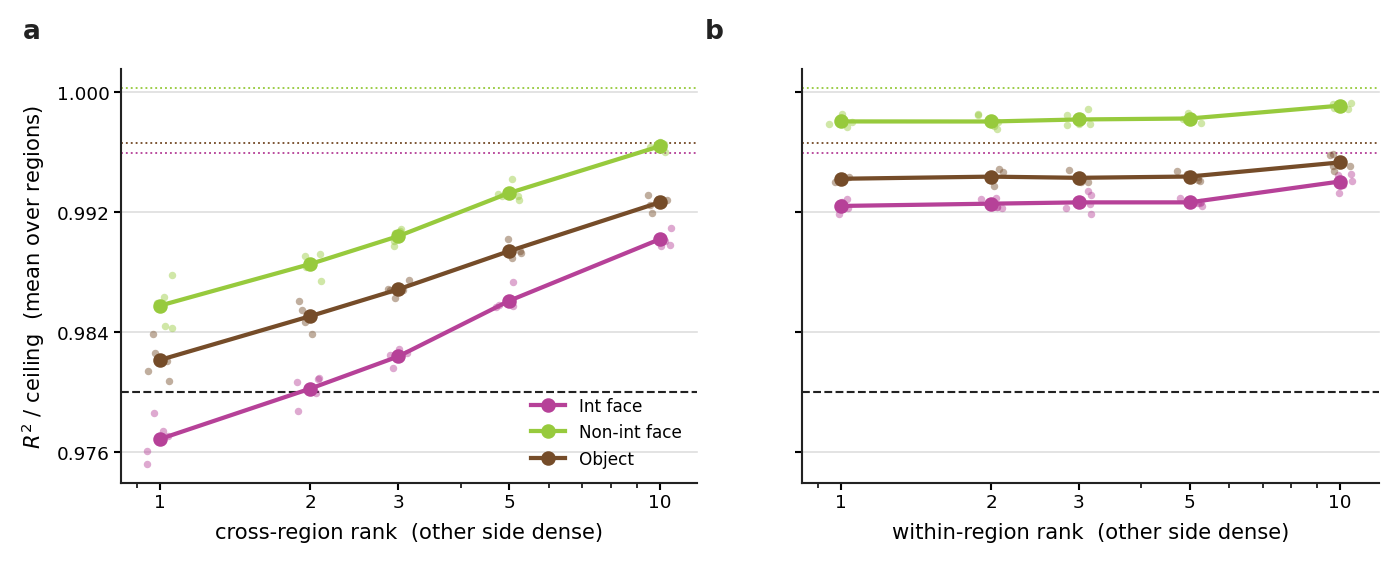

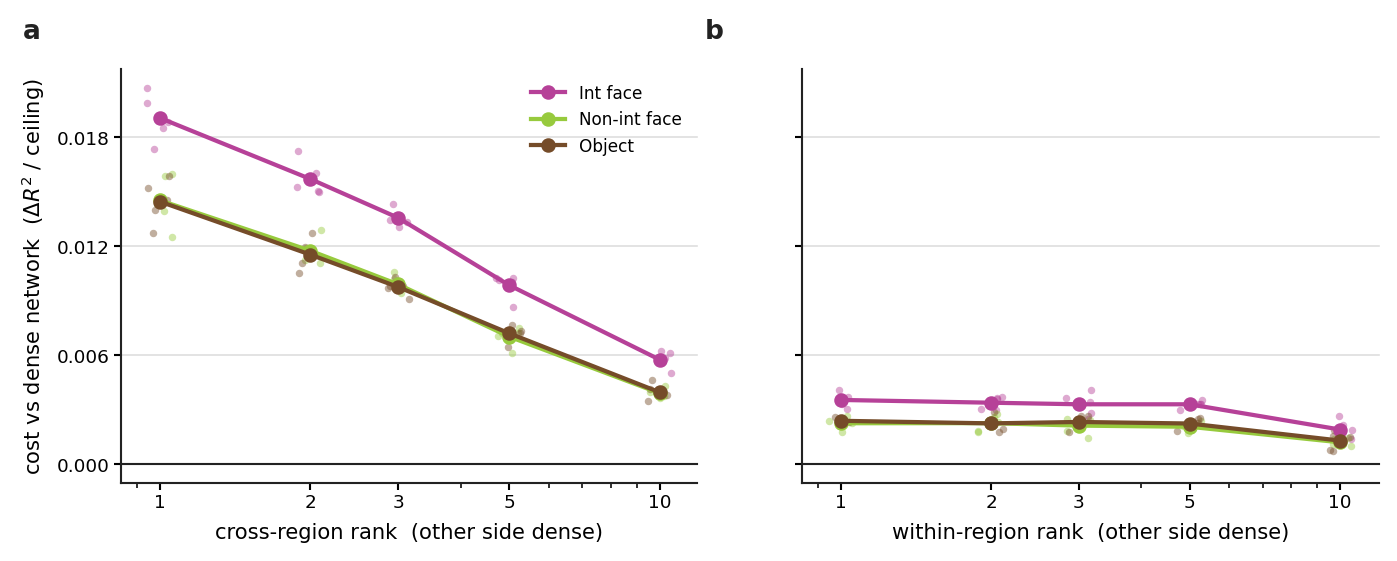

**Cost of the cross-region bottleneck relative to the dense network** (Δ $R^2$/ceiling, mean ± sd over seeds):

mean                                           std  \
condition  face_interactive face_non_interactive  object face_interactive   
rank_cross                                                                  
1                    0.0190               0.0145  0.0144           0.0013   
2                    0.0157               0.0117  0.0115           0.0009   
3                    0.0135               0.0099  0.0097           0.0005   
5                    0.0098               0.0070  0.0072           0.0007   
10                   0.0057               0.0039  0.0040           0.0005   

                                         
condition  face_non_interactive  object  
rank_cross                               
1                        0.0014  0.0012  
2                        0.0007  0.0008  
3                        0.0005  0.0004  
5                        0.0005  0.0005  
10                       0.0003  0.0005

In [2]:
show(aviz.plot_fit_by_condition_pooled(fit, hidden_units=HIDDEN_UNITS, mode="fit", dense=dense_fit, bar=ADEQUATE_BAR),
     "fig01_fit_by_condition")
show(aviz.plot_fit_by_condition_pooled(fit, hidden_units=HIDDEN_UNITS, mode="cost", dense=dense_fit),
     "fig02_cost_by_condition")

per = fit.groupby(["rank_within", "rank_cross", "seed", "condition"])["r2_vs_ceiling"].mean().reset_index()
dense_ref = dense_fit.groupby("condition")["r2_vs_ceiling"].mean()
cross_m = per[per["rank_within"] == HIDDEN_UNITS].copy()
cross_m["cost"] = cross_m["condition"].map(dense_ref) - cross_m["r2_vs_ceiling"]
cost_table = cross_m.groupby(["rank_cross", "condition"])["cost"].agg(["mean", "std"]).unstack("condition")
display(Markdown("**Cost of the cross-region bottleneck relative to the dense network** (Δ $R^2$/ceiling, mean ± sd over seeds):"))
display(cost_table.round(4))

**Conclusion.** The cross-region bottleneck costs fit; the within-region bottleneck barely
does. At rank 1 the cross channel costs 0.014–0.019 and the self blocks cost 0.002–0.0035, and
the two curves never come close at any rank. The seed spread (sd ≤ 0.0015) is smaller than the
gap between the curves. The ordering of the fixation types is the same in every panel — it is
not a property of the bottleneck (§3).

In [ ]:
## 3. Interactive face is worst throughout

The difference between interactive face and each other fixation type, per seed, along both
marginals. Below zero means interactive face is fitted worse. The dotted line is the same gap
in the dense network.

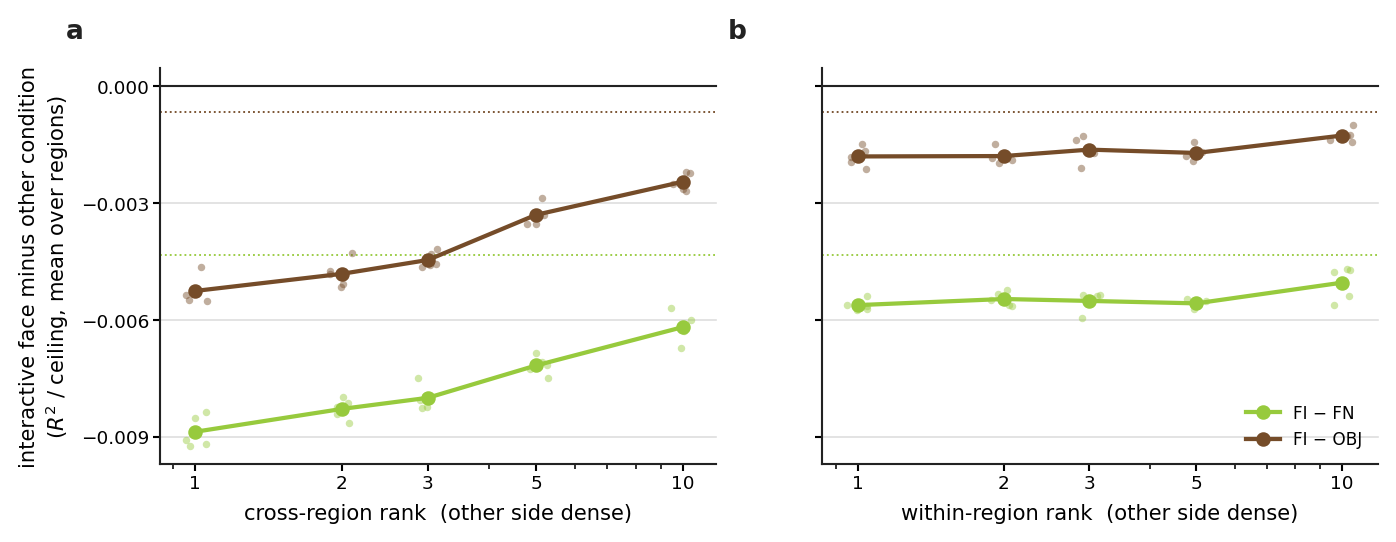

Interactive face is the worst-fitted condition in **682/700** (cell, seed, region) fits across the whole grid and **30/40** in the fully dense network.

In [3]:
show(aviz.plot_condition_gap_vs_rank(fit, hidden_units=HIDDEN_UNITS, dense=dense_fit), "fig03_condition_gap")

worst = fit.groupby(["label", "rank_within", "rank_cross", "seed", "region", "condition"])["r2_vs_ceiling"].mean().unstack("condition")
worst_fi = (worst.idxmin(axis=1) == "face_interactive")
dense_worst = dense_fit.groupby(["seed", "region", "condition"])["r2_vs_ceiling"].mean().unstack("condition")
display(Markdown(
    f"Interactive face is the worst-fitted condition in **{int(worst_fi.sum())}/{len(worst)}** (cell, seed, region) fits "
    f"across the whole grid and **{int((dense_worst.idxmin(axis=1) == 'face_interactive').sum())}/{len(dense_worst)}** "
    "in the fully dense network."))

**Conclusion.** Interactive face is the hardest fixation type in the dense network already
(dotted lines) and stays the hardest in every constrained network. The cross-region bottleneck
widens its gap to non-interactive face from −0.004 to −0.009; the within-region bottleneck
leaves it where it is. Neither changes the ordering. Interactive face being fitted worst is a
property of the data, not of the bottleneck — the fixation type has half the variance of the
other two and the minimax objective still cannot pull it level.

## 4. Regions, for completeness

Every region × condition cell, both marginals. The heatmaps show what the pooled figures
assumed: the effect is the same in every region. Interactive face is the darkest cell in each
region at each constrained rank.

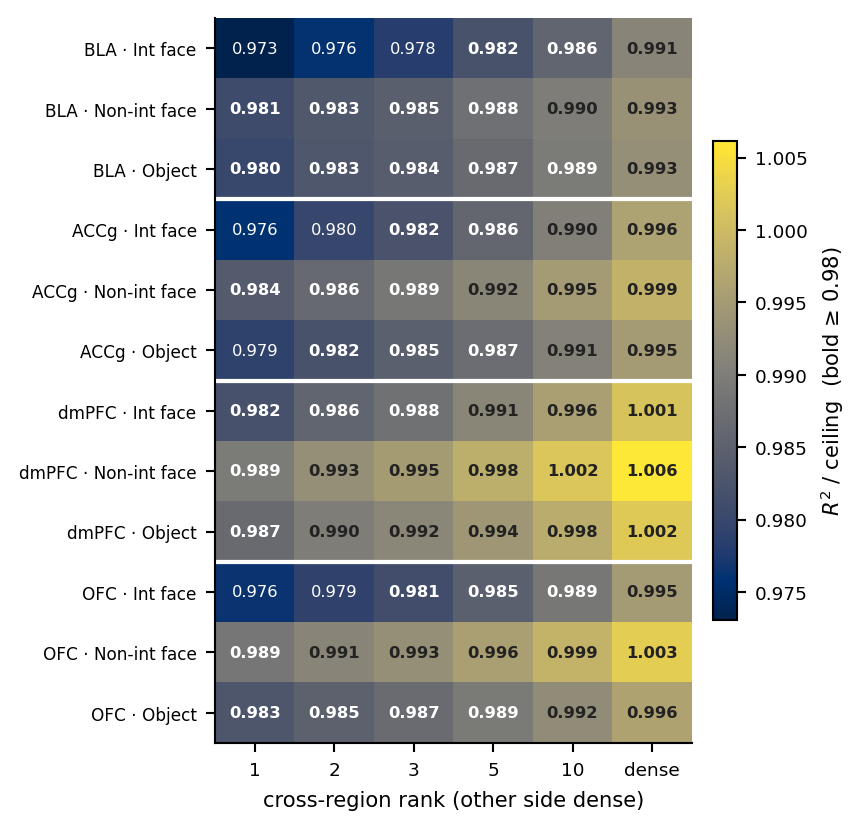

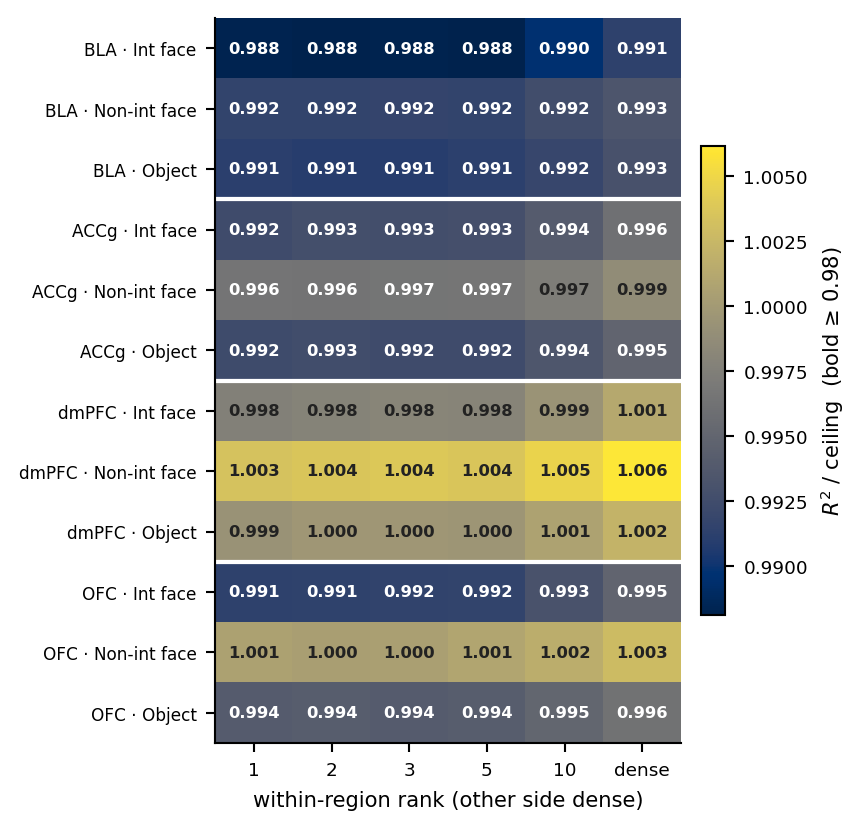

In [4]:
dense_annotated = with_ranks(dense_fit)
for side, other, stem in (("rank_cross", "rank_within", "cross"), ("rank_within", "rank_cross", "within")):
    block = pd.concat([fit[fit[other] == HIDDEN_UNITS], dense_annotated], ignore_index=True)
    block["n_partners"] = block[side]   # reuse the ladder heatmap with rank on the x-axis
    fig = aviz.plot_ladder_cell_heatmap(block, bar=ADEQUATE_BAR)
    ax = fig.axes[0]
    ax.set_xticklabels(["dense" if t.get_text() == str(HIDDEN_UNITS) else t.get_text() for t in ax.get_xticklabels()])
    ax.set_xlabel(f"{stem}-region rank (other side dense)")
    show(fig, f"fig04_{stem}_marginal_cell_heatmap")

## 5. Where a region's drive comes from

The **cross share** — the fraction of a region's drive energy that arrives from the other
three regions — along each marginal, regions pooled, seeds shown.

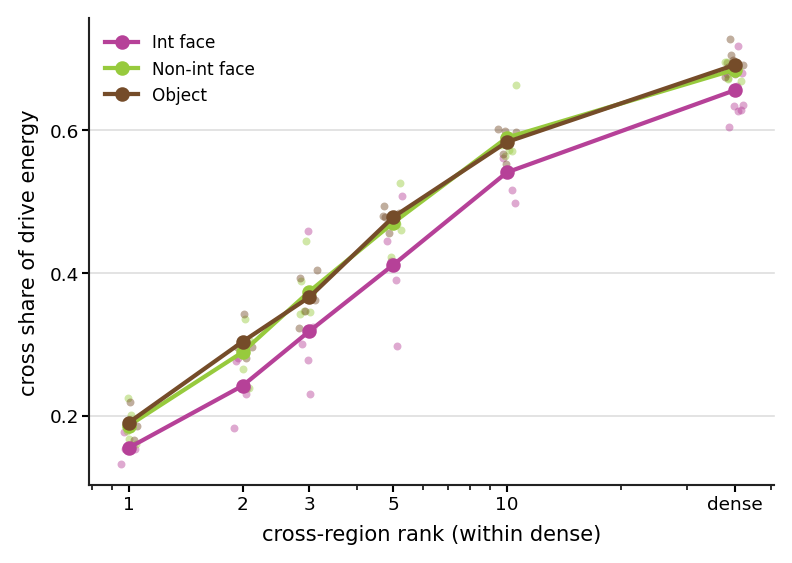

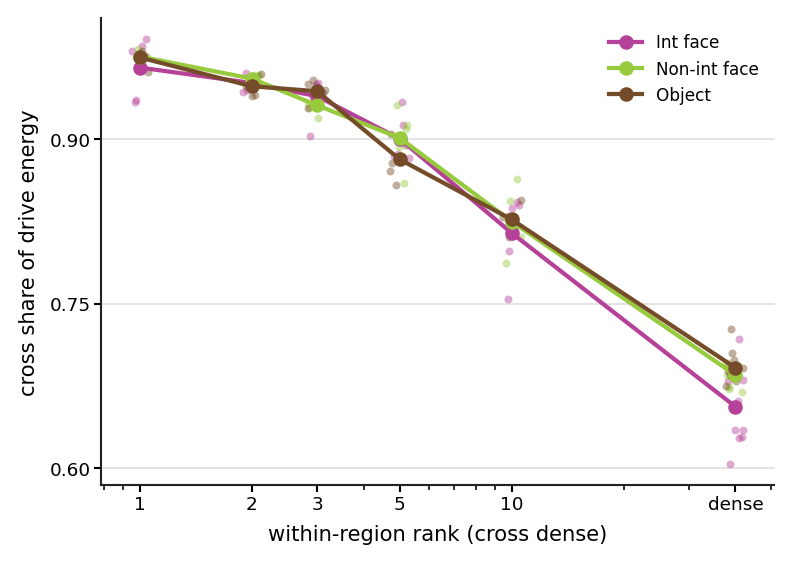

condition,face_interactive,face_non_interactive,object
label,,,
full,0.656,0.685,0.691
w1_c10,0.961,0.951,0.959
w1_c1,0.719,0.728,0.741


In [5]:
props = with_ranks(cached("region_state_properties",
                          lambda: audit.collect_over_arms(ARMS, audit.region_state_properties)))
show(aviz.plot_property_vs_rank_pooled(props[props["rank_within"] == HIDDEN_UNITS], "cross_energy_fraction",
                                       rank_column="rank_cross", hidden_units=HIDDEN_UNITS,
                                       ylabel="cross share of drive energy"), "fig05a_cross_share_vs_cross_rank")
show(aviz.plot_property_vs_rank_pooled(props[props["rank_cross"] == HIDDEN_UNITS], "cross_energy_fraction",
                                       rank_column="rank_within", hidden_units=HIDDEN_UNITS,
                                       ylabel="cross share of drive energy"), "fig05b_cross_share_vs_within_rank")
display(props.groupby(["label", "condition"])["cross_energy_fraction"].mean().unstack().loc[REFERENCE_CELLS].round(3))

**Conclusion.** The network reroutes drive in whichever direction the constraint leaves
open. Squeeze self-recurrence and the network takes over (share 0.68 → 0.97) — §2 showed that
costs ≤ 0.003. Squeeze the channel and self-recurrence takes over (share → 0.18) — §2 showed
that costs 0.015–0.019. Self-recurrence can supply a region's drive energy but not reproduce
its trajectories; the network can do both. Interactive face sits slightly lower than the other
two at every constrained cross rank, in line with §3.

## 6. Other network properties (supplementary)

Reported for completeness; none of them changes the claims above. (a) The cross share as a
time course, one panel per fixation type, thin lines individual seeds: steady and
seed-consistent in the dense network and in the selected cell, swinging within a trial and
across seeds under a rank-1 channel. (b) Alignment between incoming and self drive: mildly
positive in the dense network, zero under any cross constraint. (c) Participation ratios of the
drive and the state: 3–4 in the dense network, compressed by the cross constraint.

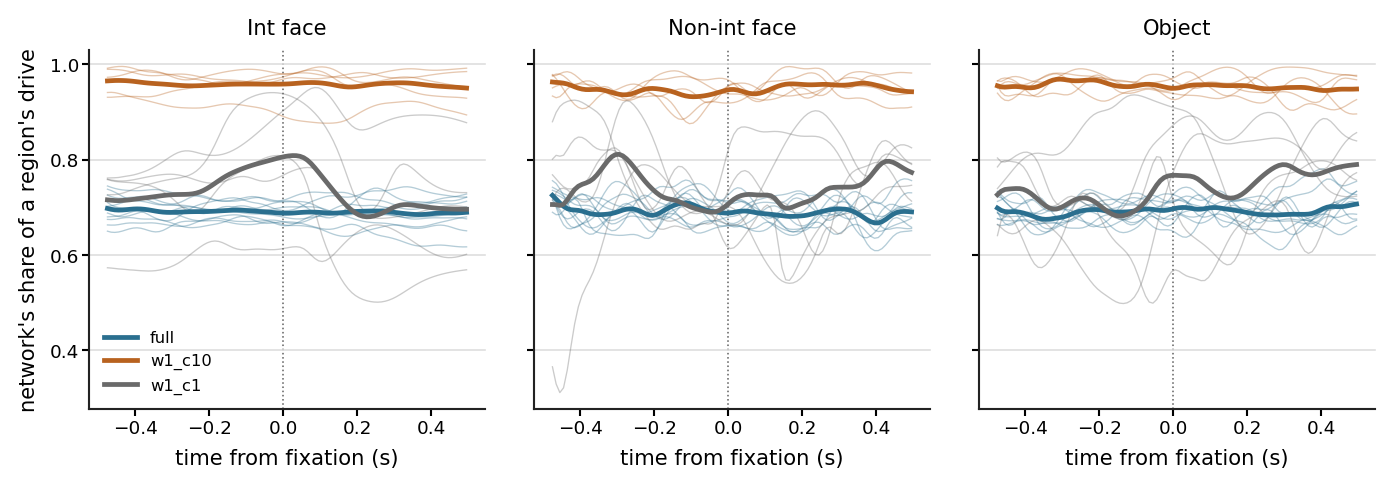

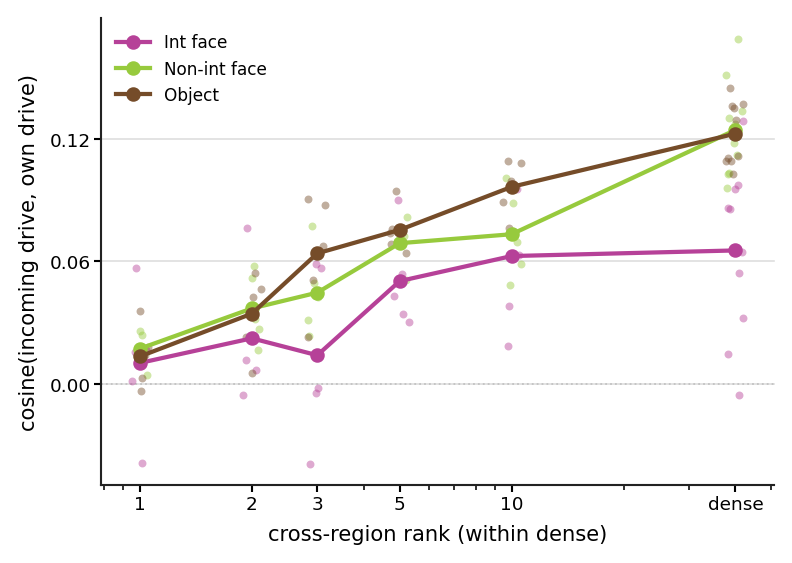

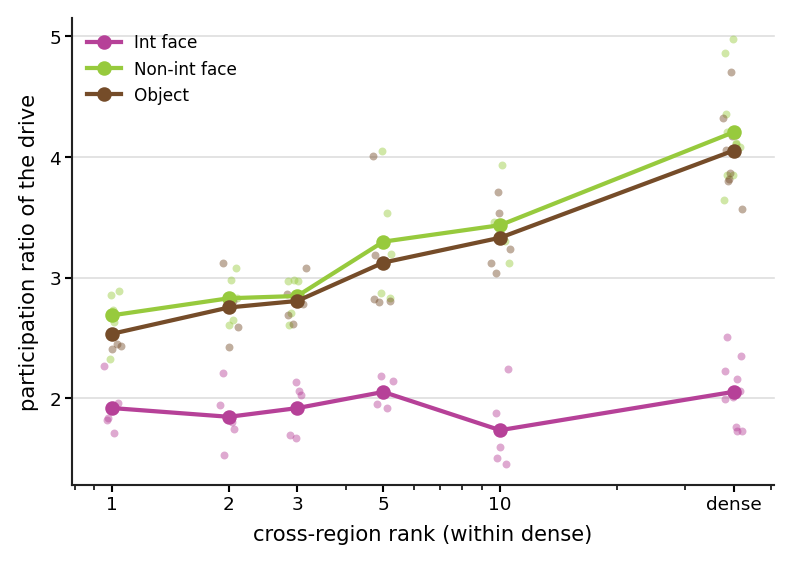

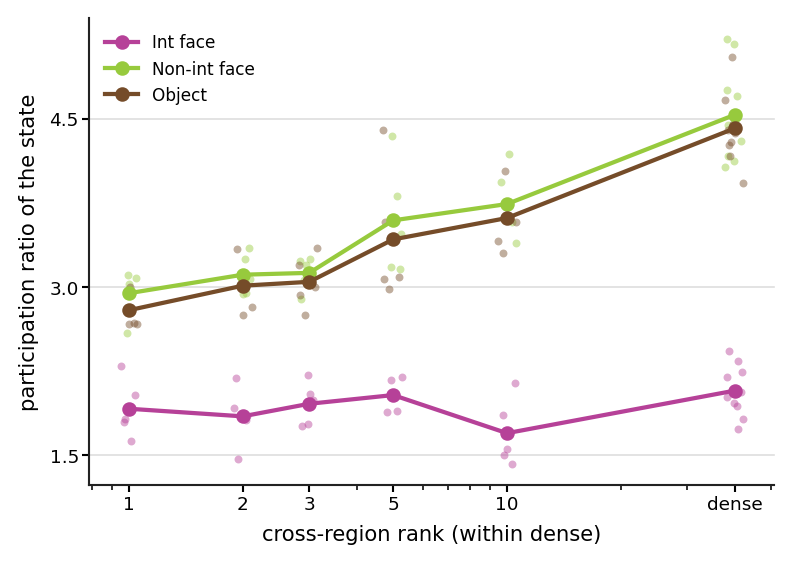

,drive_pr,self_pr,cross_pr,state_pr
label,,,,
full,3.44,3.26,3.55,3.67
w1_c10,2.65,1.00,2.65,2.88
w1_c1,1.75,1.00,1.71,1.94


In [6]:
FLOW_CELLS = [c for c in ["full"] + [v.label for v in audit.rank_grid_variants(RANKS, base_overrides={}, include_marginals=True)
                                     if v.arm != "grid" or v.label in REFERENCE_CELLS] if c in ARMS]
flow = cached("time_resolved_flow",
              lambda: audit.collect_over_arms({c: ARMS[c] for c in FLOW_CELLS}, audit.time_resolved_flow))
decomposed = audit.flow_decomposition(flow)
show(aviz.plot_flow_time_pooled(decomposed, cells=REFERENCE_CELLS), "fig06a_cross_share_time_pooled")

alignment = cached("time_resolved_alignment",
                   lambda: audit.collect_over_arms({c: ARMS[c] for c in FLOW_CELLS}, audit.time_resolved_alignment))
align_mean = with_ranks(alignment.groupby(["label", "seed", "target", "condition"])["cosine"].mean()
                        .reset_index().rename(columns={"target": "region"}))
show(aviz.plot_property_vs_rank_pooled(align_mean[align_mean["rank_within"] == HIDDEN_UNITS], "cosine",
                                       rank_column="rank_cross", hidden_units=HIDDEN_UNITS, reference=0.0,
                                       ylabel="cosine(incoming drive, own drive)"), "fig06b_alignment_vs_cross_rank")

for prop, label in (("drive_pr", "participation ratio of the drive"), ("state_pr", "participation ratio of the state")):
    show(aviz.plot_property_vs_rank_pooled(props[props["rank_within"] == HIDDEN_UNITS], prop,
                                           rank_column="rank_cross", hidden_units=HIDDEN_UNITS, ylabel=label),
         f"fig06c_{prop}_vs_cross_rank")
display(props.groupby("label")[["drive_pr", "self_pr", "cross_pr", "state_pr"]].mean().loc[REFERENCE_CELLS].round(2))

## 7. Summary

- **The cross-region bottleneck costs fit; the within-region bottleneck barely does.** Rank 1
  on the cross blocks costs 0.014–0.019; rank 1 on the self blocks costs ≤ 0.003. Same in every
  region and for every fixation type.
- **Interactive face is fitted worst in every network.** Dense or constrained, it is the
  hardest fixation type; the bottlenecks do not change that ordering.
- **The constrained network reroutes drive to whichever route is open.** Self-recurrence can
  replace the network's drive energy but not its content; the network can replace
  self-recurrence entirely.

**Next:** `03_ensemble.ipynb` refits `w1_c10` ten times and asks what those fits agree on.